In [1]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
df = pd.read_csv("PJME_hourly.csv")

df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime").reset_index(drop=True)
df = df.dropna(subset=["PJME_MW"]).reset_index(drop=True)

values = df["PJME_MW"].values.astype(np.float32)

N = len(values)
train_end = int(N * 0.70)
val_end = int(N * 0.85)

print("Dataset Shape:", df.shape)
print("Training rows:", train_end)
print("Validation rows:", val_end - train_end)
print("Testing rows:", N - val_end)

Dataset Shape: (145366, 2)
Training rows: 101756
Validation rows: 21805
Testing rows: 21805


In [3]:
scaler = StandardScaler()

scaler.fit(values[:train_end].reshape(-1, 1))

scaled_values = scaler.transform(
    values.reshape(-1, 1)
).flatten().astype(np.float32)

os.makedirs("gru_checkpoints", exist_ok=True)

joblib.dump(scaler, "gru_checkpoints/scaler.pkl")

print("Scaling completed!")

Scaling completed!


In [4]:
INPUT_LEN = 168
OUTPUT_LEN = 24

class EnergyDataset(Dataset):

    def __init__(self, data, start_indices):
        self.data = data
        self.start_indices = start_indices

    def __len__(self):
        return len(self.start_indices)

    def __getitem__(self, idx):
        start = self.start_indices[idx]

        x = self.data[start : start + INPUT_LEN]

        y = self.data[
            start + INPUT_LEN : start + INPUT_LEN + OUTPUT_LEN
        ]

        return (
            torch.tensor(x, dtype=torch.float32).unsqueeze(-1),
            torch.tensor(y, dtype=torch.float32)
        )


train_starts = np.arange(
    0, train_end - INPUT_LEN - OUTPUT_LEN + 1
)

val_starts = np.arange(
    train_end - INPUT_LEN,
    val_end - INPUT_LEN - OUTPUT_LEN + 1
)

test_starts = np.arange(
    val_end - INPUT_LEN,
    N - INPUT_LEN - OUTPUT_LEN + 1
)

train_dataset = EnergyDataset(scaled_values, train_starts)
val_dataset = EnergyDataset(scaled_values, val_starts)
test_dataset = EnergyDataset(scaled_values, test_starts)

print("Training sequences:", len(train_dataset))
print("Validation sequences:", len(val_dataset))
print("Testing sequences:", len(test_dataset))

Training sequences: 101565
Validation sequences: 21782
Testing sequences: 21782


In [5]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("DataLoaders ready!")

DataLoaders ready!


In [6]:
class GRUModel(nn.Module):

    def __init__(
        self,
        input_size=1,
        hidden_size=64,
        num_layers=2,
        output_size=24,
        dropout=0.2
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.gru(x)
        last_output = out[:, -1, :]
        return self.fc(last_output)


model = GRUModel().to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=24, bias=True)
)


In [8]:
import torch

checkpoint = torch.load(
    "gru_checkpoints/last_checkpoint.pth",
    map_location="cpu",
    weights_only=False
)

print("Last completed epoch:", checkpoint["epoch"] + 1)
print("Best validation loss:", checkpoint["best_val_loss"])

Last completed epoch: 21
Best validation loss: 0.0736334043721562


In [9]:
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=device,
        weights_only=True
    )
)

model.eval()
all_predictions = []
all_actuals = []

with torch.no_grad():

    for x, y in test_loader:

        x = x.to(device)

        predictions = model(x).cpu().numpy()

        all_predictions.append(predictions)
        all_actuals.append(y.numpy())


predictions_scaled = np.concatenate(all_predictions, axis=0)
actuals_scaled = np.concatenate(all_actuals, axis=0)

# Convert predictions back to MW
predictions_mw = scaler.inverse_transform(
    predictions_scaled.reshape(-1, 1)
).reshape(-1, OUTPUT_LEN)

actuals_mw = scaler.inverse_transform(
    actuals_scaled.reshape(-1, 1)
).reshape(-1, OUTPUT_LEN)

mae = mean_absolute_error(
    actuals_mw.flatten(),
    predictions_mw.flatten()
)

rmse = np.sqrt(mean_squared_error(
    actuals_mw.flatten(),
    predictions_mw.flatten()
))

wape = (
    np.sum(np.abs(actuals_mw - predictions_mw))
    / np.sum(np.abs(actuals_mw))
) * 100

print(f"GRU Test MAE:  {mae:.2f} MW")
print(f"GRU Test RMSE: {rmse:.2f} MW")
print(f"GRU Test WAPE: {wape:.2f}%")



GRU Test MAE:  1373.72 MW
GRU Test RMSE: 1954.52 MW
GRU Test WAPE: 4.42%


In [16]:
pred_df = pd.DataFrame()

for i in range(OUTPUT_LEN):

    pred_df[f"Actual_Hour_{i+1}"] = actuals_mw[:, i]

    pred_df[f"Predicted_Hour_{i+1}"] = predictions_mw[:, i]


pred_df.to_csv("gru_test_predictions.csv", index=False)

print("GRU predictions saved!")

GRU predictions saved!


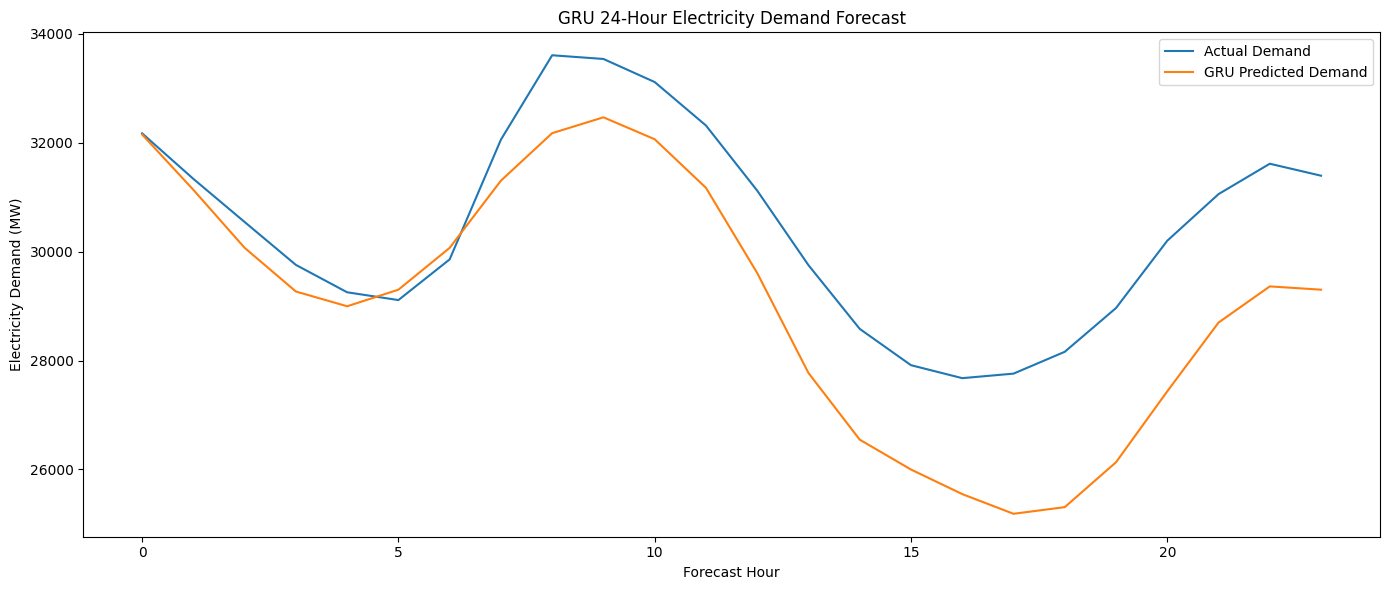

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    actuals_mw[0],
    label="Actual Demand"
)

plt.plot(
    predictions_mw[0],
    label="GRU Predicted Demand"
)

plt.xlabel("Forecast Hour")
plt.ylabel("Electricity Demand (MW)")
plt.title("GRU 24-Hour Electricity Demand Forecast")
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_5_2_GRU_Forecast_Output.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()